In [1]:
import io, contextlib
import numpy as np, matplotlib.pyplot as plt
import dismech
from dismech.materials import *

In [9]:
b = 0.02
h = 0.001

def build_robot():
    geom = dismech.GeomParams(rod_r0=0.001, 
                              shell_h=0,
                              axs=b*h, 
                              ixs1=b*h**3/12,
                              ixs2=h*b**3/12, 
                              jxs=b*h**3/6)

    sim = dismech.SimParams(static_sim=False, 
                            two_d_sim=False, 
                            use_mid_edge=False,
                            use_line_search=False, 
                            show_floor=False,
                            log_data=True, 
                            log_step=1, 
                            dt=1e-2, 
                            max_iter=25,
                            total_time=1.0, 
                            plot_step=1,
                            tol=1e-4, 
                            ftol=1e-4, 
                            dtol=1e-2)

    env = dismech.Environment()
    env.add_force('gravity', g=np.array([0.0, 0.0, -9.81]))   # constant gravity, no ramp

    geo = dismech.Geometry.from_txt('../tests/resources/rod_cantilever/horizontal_rod_n51.txt')
    robot = dismech.SoftRobot(geom, aluminum_6061, geo, sim, env)
    return robot.fix_nodes(np.arange(6))                      # nodes 0-5 are fixed

In [16]:
tip_z = dismech.SoftRobot.map_node_to_dof(50)[2]      # z slot of the tip node
free_nodes = np.arange(6, 51)                          # nodes 0-5 are fixed
velocities = np.linspace(0, 0.5, 5)                      # 5 values: 0, 0.25, 0.5, 0.75, 1.0 m/s

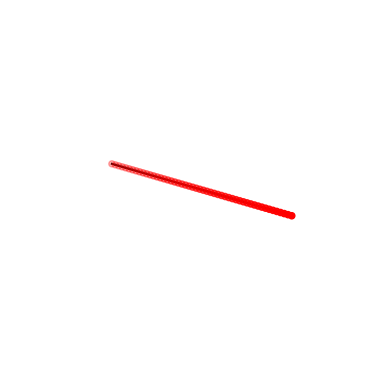

C:\Users\ryane\Research\Soft-Robot-Modeling-with-PyDiSMech\src\dismech\elastics\stretch_energy.py:49: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  M2 = np.divide(M2, eps[:, None, None], where=mask[:, None, None])


v0 = 0.00 m/s -> tip z max 0.000 mm, min -0.040 mm


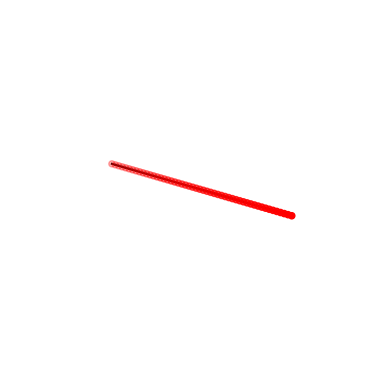

v0 = 0.12 m/s -> tip z max 0.011 mm, min -0.041 mm


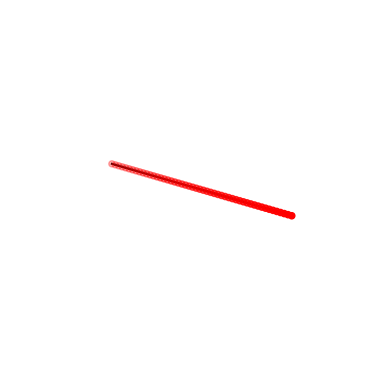

v0 = 0.25 m/s -> tip z max 0.060 mm, min -0.042 mm


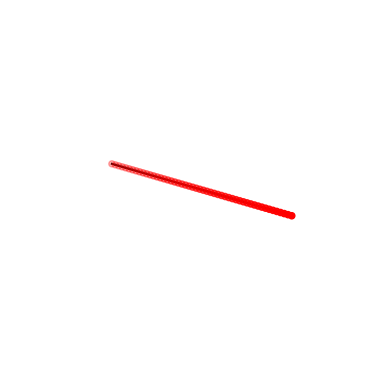

v0 = 0.38 m/s -> tip z max 0.109 mm, min -0.043 mm


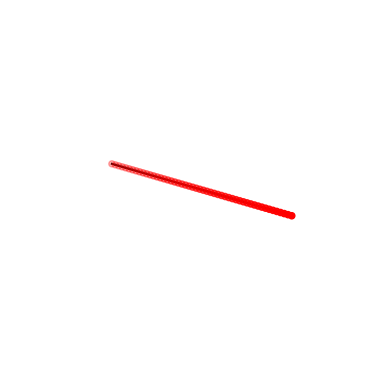

v0 = 0.50 m/s -> tip z max 0.158 mm, min -0.044 mm


In [17]:
peak_up, peak_down, tip_curves = [], [], {}
for v in velocities:
    # Rebuild everything each run so no state leaks between runs
    robot = build_robot()                              # already has nodes 0-5 fixed
    stepper = dismech.ImplicitEulerTimeStepper(robot)

    u0 = np.zeros_like(robot.state.q)
    u0[3*free_nodes + 2] = v                           # z component only, free nodes only
    robot = robot.update(u=u0)
    try:
        with contextlib.redirect_stdout(io.StringIO()):  # silence per-iteration solver prints
            robots, _, _ = stepper.simulate(robot)
        z = np.array([r.state.q[tip_z] for r in robots])
        tip_curves[v] = z
        peak_up.append(z.max())                        # highest point the tip reaches
        peak_down.append(z.min())                      # lowest point the tip reaches
        print(f"v0 = {v:.2f} m/s -> tip z max {z.max()*1e3:.3f} mm, min {z.min()*1e3:.3f} mm")
    except Exception as e:
        peak_up.append(np.nan)                         # solver diverged at this speed
        peak_down.append(np.nan)
        print(f"v0 = {v:.2f} m/s -> FAILED: {e}")

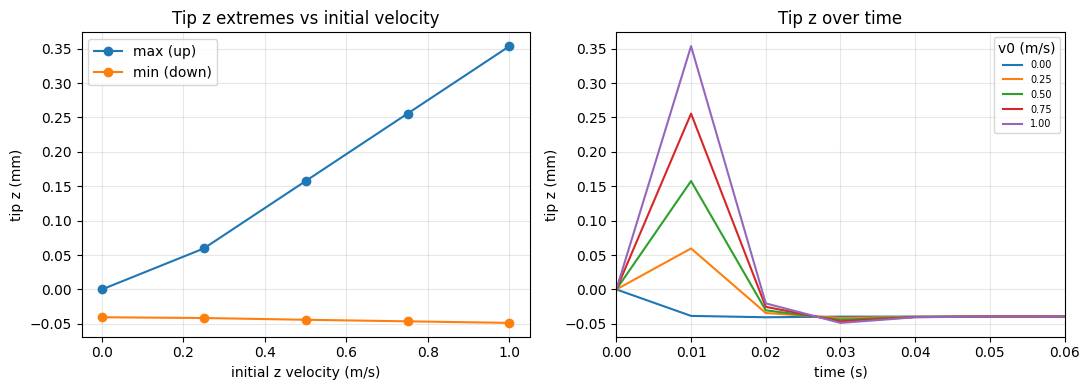

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(velocities, np.array(peak_up)*1e3, 'o-', label='max (up)')
ax[0].plot(velocities, np.array(peak_down)*1e3, 'o-', label='min (down)')
ax[0].set_xlabel('initial z velocity (m/s)')
ax[0].set_ylabel('tip z (mm)')
ax[0].set_title('Tip z extremes vs initial velocity')
ax[0].legend()
ax[0].grid(alpha=0.3)

dt = 1e-2
settle_frac = 0.02
t_settle = 0.0

for v, z in tip_curves.items():
    z = np.asarray(z)
    t = np.arange(len(z)) * dt
    ax[1].plot(t, z*1e3, label=f"{v:.2f}")
    tol = settle_frac * max(np.ptp(z), 1e-12)
    outside = np.where(np.abs(z - z[-1]) > tol)[0]
    if outside.size:
        t_settle = max(t_settle, t[outside[-1] + 1] if outside[-1] + 1 < len(t) else t[-1])

ax[1].set_xlim(0, max(t_settle * 1.5, 5 * dt))
ax[1].set_xlabel('time (s)')
ax[1].set_ylabel('tip z (mm)')
ax[1].set_title('Tip z over time')
ax[1].legend(title='v0 (m/s)', fontsize=7)
ax[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()